## Lean 2D Straight Line Class (`Sline2d_leanest`) & Full-Featured 2D Straight Line (`Sline2d`)

# Sline2d_leanest: Lightweight 2D Straight Line

This notebook demonstrates the **lean** variant of UPXO's 2D straight-line class (`Sline2d_leanest`), designed for memory-efficient representation using raw coordinates (x₀, y₀, x₁, y₁) instead of full `Point2d` objects. It covers:

- **Construction methods**: `by_coord`, direct instantiation  
- **Core properties**: `length`, `gradient`, orientation checks  
- **Geometric queries**: `contains_point`, distance calculations  

Use the lean class when performance and minimal memory footprint are priorities.

---

# Sline2d: Full-Featured 2D Straight Line

The **full `Sline2d`** class extends the lean version with rich constructors, integrated `Point2d` support, and advanced geometric operations. This is the primary workhorse for 2D line manipulation in UPXO.

## Key Features

### Rich Construction Methods
- **`by_coord`**, **`by_p2d`**: From coordinates or `Point2d` objects  
- **`by_MCL`**, **`by_MCLC`**: From slope (m), y-intercept (c), length (L), optional center  
- **`by_general_form`**: From implicit equation Ax + By + C = 0  
- **`by_point_dxdy`**: From point and direction vector [dx, dy]  
- **`by_LFGL`**: Location, factor (position along line), gradient, length  
- **`by_LFAL`**: Location, factor, angle, length  
- **`by_perp_bisector`**: Perpendicular bisector between line and point  

### Core Properties
- **Geometry**: `length`, `gradient`, `dxdy`, `dx`, `dy`, `yint`, `ang`, `angd`  
- **Orientation**: `vert` (vertical), `horz` (horizontal)  
- **Coordinates**: `coords`, `coord_list`, `coord_i`, `coord_j`, `general_form`  
- **Conversion**: `lean` (return `Sline2d_leanest` equivalent)  

### Geometric Operations
- **Point queries**: `contains_point`, `fully_contains_point`, `is_point_endpoint`  
- **Line queries**: `contains_sl2d` (check if another line is contained)  
- **Distance**: `perpendicular_distance`  
- **Transformations**: `flip`, `invert`, `move_i`, `move_j`, `move_to_location`  
- **Subdivision**: `break_up` (divide into n segments), `divide_at_ratios`  
- **Point distribution**: `distribute_points` (constant/parametric spacing)  
- **Relationships**: `is_normal` (perpendicularity check)  

## When to Use Each Class

| Use Case | Recommended Class |
|----------|-------------------|
| Memory-critical applications, large datasets | `Sline2d_leanest` |
| Need rich constructors (slope-intercept, parametric, etc.) | `Sline2d` |
| Integration with `Point2d` ecosystem | `Sline2d` |
| Advanced transformations & subdivisions | `Sline2d` |
| Simple segment representation | `Sline2d_leanest` |

Both classes share core functionality for `gradient`, `length`, and `contains_point`, ensuring consistent behavior across the UPXO geometry stack.

Briefly imports lean/full straight-line classes plus numpy/matplotlib/random to support all subsequent 2D line demonstrations.

In [1]:
from upxo.geoEntities.sline2d import Sline2d_leanest as sl2dl
from upxo.geoEntities.sline2d import Sline2d_leanest as sl2dlean
import numpy as np
import matplotlib.pyplot as plt
import random

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


### by_coord
Create Sline2d by specifying end coordinates.

#### Parameters
- start: Starting point coordinate [x0, y0]
- end: Ending point coordinate [x1, y1]

Instantiate a lean line via `by_coord` using explicit start/end coordinates and print the resulting object for inspection.

In [2]:
A = sl2dlean.by_coord([-1, 2], [3, 4])
print(A)

UPXO-sl2d-lean (-1,2)-(3,4)


### length

Construct a lean line and query its `length` property to show direct access without explicit method calls.

In [3]:
e = sl2dl(-2, 3, 4, 5)
e.length

6.324555320336759

### gradient
Return the gradienyt of the self line.

Evaluate `gradient` for two lines (generic slope and vertical) to illustrate positive slope and infinite-slope handling.

In [4]:
e = sl2dl(-2, 3, 4, 5)
print(e.gradient)

e = sl2dl(0, 1, 0, 2)
print(e.gradient)

0.3333333333333333
inf


### contains_point
#### Explantions
Assess relative positioning of a point with respect to self edge.
Output helps determine whether the point:
1. is fully contained inside the self edge
2. is coincident with one of the points of the self edge
3. is located on the extended part of the self edge
4. none of the above. Relative position unknown.

#### Parameters
**obj** : coord, UPXO point2d object
    Represents a point in space. The default is None.
**tdist** : TYPE, optional
    Tolerance distance. The default is 0.0.

#### Returns
**intersection** : [bool, bool, bool]<br>
Provides the relative position of point with resepect to self edge.
1. *Contains the point.* It coincides with one of the edge points.
   The truth values in 'intersection' are *[True, False, True]*.
2. *Contains the point.* Point is fully inside the edge.
   The truth values in 'intersection' are *[True, False, False]*.
3. *Point is on the extended edge.*
   The truth values in 'intersection' are *[False, True, False]*.
4. *Relative position of point unknown.*
   The truth values in 'intersection' are *[False, False, False]*.

Run `contains_point` across coords and `Point2d` instances (on-edge, endpoints, off-edge) plus a degenerate zero-length line case to show boolean tuple outputs.

In [5]:
from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.sline2d import Sline2d
from upxo.geoEntities.sline2d import Sline2d_leanest as sl2dlean
e = sl2dlean.by_coord([-1, 0], [1, 0])

print(e.contains_point([-0.5, 0]))
print(e.contains_point([0, 0]))
print(e.contains_point([-1, 0]))
print(e.contains_point([1, 0]))
print(e.contains_point([-1.1, 0]))
print(e.contains_point([-1.1, 1]))

print(e.contains_point(Point2d(-0.5, 0)))
print(e.contains_point(Point2d(0, 0)))
print(e.contains_point(Point2d(-1, 0)))
print(e.contains_point(Point2d(1, 0)))
print(e.contains_point(Point2d(-1.1, 0)))
print(e.contains_point(Point2d(-1.1, 1)))

e = Sline2d(pnta=Point2d(1, 0), pntb=Point2d(1, 0))
print(e.contains_point([0.8, 0.2]))
print(e.contains_point(Point2d(0.8, 0.2)))

[True, False, False]
[True, False, False]
[True, False, True]
[True, False, True]
[False, True, False]
[False, False, False]
[True, False, False]
[True, False, False]
[True, False, True]
[True, False, True]
[False, True, False]
[False, False, False]
[False, False, False]
[False, False, False]


---

## Sline2d: 2D Straight line object.
**End points are:**
1. start (i.e. i): x0 & y0
2. end (i.e. j): x1 & y1

**Following are the creation methods:**
* Default creation is by specifying `__init__`(x0, y0, x1, y1).
* by_coord(start, end).
* by_point_slope(point, slope).
* by_slope_intercept(slope, intercept).
* by_parametric(point1, point2, N).
* by_coeff_const(a, b, c).
* by_vector(point, xyproj).
* by_loc_len_ang(ref='i', loc=[0, 0, 0], length=1, ang=0, degree=True).
* by_perp_bisector(line, point).
* by_transform(refedge=None, shiftxy=[0, 1], rot=+45, degree=True,
                       rot_pnt_f=0.5).
* by_dist_bw_points(refpoint=None, points=None, f).

**Following are the property attributes:**
* length: Length of the line
* gradient: Gradient of the line
* mid: midpoint of the line
* ang: angle in radians
* angd: angle in degrees
* vert: True if line is vertical
* horz: True if horizontal
* lean: Return lean representation of self.

**Import**
from upxo.geoEntities.sline2d import Sline2d

Import full `Sline2d` and `Point2d` to demonstrate rich constructor variants alongside the lean version above.

In [6]:
from upxo.geoEntities.sline2d import Sline2d as sl2d
from upxo.geoEntities.point2d import Point2d as p2d

Create identical lines via raw coordinate pairs and via `Point2d` inputs to compare constructors.

In [7]:
print(sl2d.by_coord([-1, 2], [3, 4]))
print(sl2d.by_p2d(p2d(-1, 2), p2d(3, 4)))

UPXO-sl2d (-1,2)-(3,4). 2302098429888
UPXO-sl2d (-1,2)-(3,4). 2302098344928


### by_MCL
#### Explanatiopon
Instantiate the Sline2d using slope, intercept and length.

#### Parameters
- **gradient**: Slope of the 2D line
- **intercept**: Y-intercept opf the straight line
- **length**: Lenght of the straight line

#### Return
Instant of Sline2d

Instantiate via `by_MCL` using slope, intercept, and length to see the centered line placement.

In [8]:
Sline2d.by_MCL(1.0, -1, 1)

UPXO-sl2d (0,-1)-(0.707107,-0.292893). 2302098430656

### by_MCLC
#### Explanation
Instantiate Sline2d using m, c and L, centred at centre-(cx, cy).

#### Explanations
MCLC: Gradient, Y-intercept, Length, Centre

#### Parameters
- **gradient**: Slope of the 2D line
- **intercept**: Y-intercept opf the straight line
- **length**: Lenght of the straight line
- **centre**: Proposed x- and y-location of line midpoint: (cx, cy)

#### Return
Instant of Sline2d

Show `by_MCLC` examples with varying intercepts/centers to illustrate how midpoint positioning shifts the generated segment.

In [9]:
print(Sline2d.by_MCLC(1.0, 0, 2.0, (-10.0, -10.0)))
print(Sline2d.by_MCLC(1.0, -1.0, 2.0, (-10.0, -5.0)))

UPXO-sl2d (-10.707107,-10.707107)-(-9.292893,-9.292893). 2302098431136
UPXO-sl2d (-10.707107,-5.707107)-(-9.292893,-4.292893). 2302098431136


### by_general_form
Instnatiate a line represented in the general form (Ax+By+C=0).
line = [A, B, C]

Create a line from general-form coefficients (A,B,C) to verify parsing of implicit line equations.

In [10]:
Sline2d.by_general_form(1, 1, 0.2)

UPXO-sl2d (0,-0.2)-(-0.2,0). 2302098431520

### by_point_dxdy
A line can be represented using a point on the line and a dir. vector.
line = [[x, y], [dx, dy]]

Build a line from a base point and direction vector `[dx, dy]` to emphasize vector-based initialization.

In [11]:
Sline2d.by_point_dxdy([1, 1], [2, 3])

UPXO-sl2d (1,1)-(3,4). 2302098527424

### by_LFGL
Create Sline2d by specifying location, factor, gradient and length.
#### Issue
Line creation issue when gradient is infinity.
Example: sl2d.by_LFGL(location=[0, 0], factor=0.0, gradient=math.inf, length=1)

Exercise `by_LFGL` (location, factor, gradient, length) with multiple slopes including infinity to observe construction and edge cases.

In [12]:
print(sl2d.by_LFGL(location=[0, 0], factor=0.0, gradient=0, length=1))
print(sl2d.by_LFGL(location=[0, 0], factor=0.0, gradient=1, length=1))
print(sl2d.by_LFGL(location=[0, 0], factor=0.0, gradient=-1, length=1))
print(sl2d.by_LFGL(location=[0, 0], factor=1.0, gradient=0, length=1))
import math
sl2d.by_LFGL(location=[0, 0], factor=0.0, gradient=math.inf, length=1)

UPXO-sl2d (0.0,0.0)-(1.0,0.0). 2302098527712
UPXO-sl2d (0.0,0.0)-(0.707107,0.707107). 2302098527136
UPXO-sl2d (0.0,0.0)-(0.707107,-0.707107). 2302098527712
UPXO-sl2d (-1.0,0.0)-(0.0,0.0). 2302098527136


c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\geoEntities\sline2d.py:578: RuntimeWarning: invalid value encountered in divide
  unit_dir = (1, gradient) / np.sqrt(1 + gradient**2)


UPXO-sl2d (0.0,nan)-(0.0,nan). 2302098527136

### by_LFAL
#### Explanation
Create Sline2d by specifying location, factor, angle and length.

#### Parameters
- **ref**: Specifies which point on the line is used to spcify the edge.
- **loc**: Specifies the ref point.
- **length**: Length of the line to be made.
- **angle**: Angle(s) of inclination of the line. If 2D, single value. If 3D, this specifies a list of three angles. First angle
- **degree**: ang considered in degree if degree is True, in radians if otherwise.

Call `by_LFAL` with varying factors/angles to show how location+angle+length generate lines in different quadrants; includes origin and offset examples.

In [13]:
_cdef_ = sl2d.by_LFAL  # Class definition i.e. class method

loc = [0, 0]
print(_cdef_(location=loc, factor=0.0, angle=0, length=1, degree=True))
print(_cdef_(location=loc, factor=1.0, angle=0, length=1, degree=True))
print(_cdef_(location=loc, factor=0.5, angle=0, length=1, degree=True))

print(_cdef_(location=loc, factor=0.0, angle=90, length=1, degree=True))
print(_cdef_(location=loc, factor=0.0, angle=-90, length=1, degree=True))
print(_cdef_(location=loc, factor=1.0, angle=-90, length=1, degree=True))

loc = [10, 10]
print(_cdef_(location=loc, factor=0.0, angle=45, length=1, degree=True))
print(_cdef_(location=loc, factor=0.0, angle=-45, length=1, degree=True))
print(_cdef_(location=loc, factor=1.0, angle=45, length=1, degree=True))
print(_cdef_(location=loc, factor=1.0, angle=-45, length=1, degree=True))

print(_cdef_(location=loc, factor=0.5, angle=45, length=1, degree=True))
print(_cdef_(location=loc, factor=0.5, angle=-45, length=1, degree=True))
print(_cdef_(location=loc, factor=0.2, angle=45, length=1, degree=True))
print(_cdef_(location=loc, factor=0.8, angle=-45, length=1, degree=True))

UPXO-sl2d (0.0,0.0)-(1.0,0.0). 2302098527328
UPXO-sl2d (-1.0,0.0)-(0.0,0.0). 2302098819104
UPXO-sl2d (-0.5,0.0)-(0.5,0.0). 2302098819200
UPXO-sl2d (0.0,0.0)-(0.0,1.0). 2302098819296
UPXO-sl2d (0.0,0.0)-(0.0,-1.0). 2302098819392
UPXO-sl2d (-0.0,1.0)-(0.0,0.0). 2302098819488
UPXO-sl2d (10.0,10.0)-(10.707107,10.707107). 2302098819584
UPXO-sl2d (10.0,10.0)-(10.707107,9.292893). 2302098819488
UPXO-sl2d (9.292893,9.292893)-(10.0,10.0). 2302098819584
UPXO-sl2d (9.292893,10.707107)-(10.0,10.0). 2302098819488
UPXO-sl2d (9.646447,9.646447)-(10.353553,10.353553). 2302098819584
UPXO-sl2d (9.646447,10.353553)-(10.353553,9.646447). 2302098819488
UPXO-sl2d (9.858579,9.858579)-(10.565685,10.565685). 2302098819584
UPXO-sl2d (9.434315,10.565685)-(10.141421,9.858579). 2302098819488


### by_perp_bisector
#### Explanations
Calculate and make the perpendicular bisector Sline2d b/w line and a point.

#### Parameters
- **e**: Edge specification. Preferred: UPXO edge2d_leanest
- **p**: POint specificaiton. Preferred: UPXO point2d_leanest

Placeholder to remind that perpendicular bisector implementation is pending for `by_perp_bisector`.

In [1]:
#### Code pending

### gradient

Compute gradients for diagonal, negative, vertical, and horizontal lines to show finite vs infinite slope outcomes.

In [15]:
print(sl2d.by_coord([-1, 2], [3, 4]).gradient)
print(sl2d.by_coord([-1, -1], [1, 1]).gradient)
print(sl2d.by_coord([0, 0], [0, 1]).gradient)
print(sl2d.by_coord([0, 0], [1, 0]).gradient)

0.5
1.0
inf
0.0


### dxdy, dx, dy, yint, ang, angd, length, vert, horz, lean
- **dxdy**: Return the length increments along x and y.<br>
- **dx**: Return the length increment along x.<br>
- **dy**: Return the length increment along y.<br><br>
- **yint**: Return the y-intercept of the line.<br>
- **ang**: Return the ccw + angle in radians.<br><br>
- **angd**: Return the ccw + angle in degrees.<br>
- **length**: Calculate and return self length.<br><br>
- **vert**: Return True if the line is vertical.<br>
- **horz**: Return True if the line is horizontal.<br><br>
- **lean**: Return lean representation of self.

Sample property access (`dxdy`, `yint`, `ang/angd`, `length`) across multiple orientations to illustrate derived geometry values.

In [16]:
a = sl2d(0,0, 1,1)
print(40*'-', '\ndxdy, dx, dy \n')
print(a.dxdy, a.dx, a.dy)
print(40*'-', '\nyint \n')
print(sl2d.by_coord([-1, 2], [3, 4]).yint)
print(sl2d.by_coord([-1, -1], [1, 1]).yint)
print(sl2d.by_coord([0, 0], [0, 1]).yint)
print(sl2d.by_coord([0, 0], [1, 0]).yint)
print(sl2d.by_coord([0, -1], [1, -1]).yint)
print(40*'-', '\nang \n')
print(sl2d.by_coord([-1, 2], [3, 4]).ang)
print(sl2d.by_coord([-1, -1], [1, 1]).ang)
print(sl2d.by_coord([0, 0], [0, 1]).ang)
print(sl2d.by_coord([0, 0], [1, 0]).ang)
print(sl2d.by_coord([0, -1], [1, -1]).ang)
print(40*'-', '\nangd \n')
print(sl2d.by_coord([-1, 2], [3, 4]).angd)
print(sl2d.by_coord([-1, -1], [1, 1]).angd)
print(sl2d.by_coord([0, 0], [0, 1]).angd)
print(sl2d.by_coord([0, 0], [1, 0]).angd)
print(sl2d.by_coord([0, -1], [1, -1]).angd)
print(40*'-', '\nlength \n')
print(sl2d.by_coord([-1, 2], [3, 4]).length)
print(sl2d.by_coord([-1, -1], [1, 1]).length)
print(sl2d.by_coord([0, 0], [0, 1]).length)
print(sl2d.by_coord([0, 0], [1, 0]).length)
print(sl2d.by_coord([0, -1], [1, -1]).length)

---------------------------------------- 
dxdy, dx, dy 

(1, 1) 1 1
---------------------------------------- 
yint 

2.5
0.0
inf
0.0
-1.0
---------------------------------------- 
ang 

0.4636476090008061
0.7853981633974483
1.5707963267948966
0.0
0.0
---------------------------------------- 
angd 

26.56505117707799
45.0
90.0
0.0
0.0
---------------------------------------- 
length 

4.47213595499958
2.8284271247461903
1.0
1.0
1.0


### coords, coord_list
Return coordinate array.

Inspect different coordinate views (`coords`, `coord_list`, `coord_i/j`) for a simple line to clarify return shapes.

In [17]:
a = sl2d(0,0, 1,1)
print(a.coords)
print(a.coord_list)
print(a.coord_i)
print(a.coord_j)

[0, 0, 1, 1]
[[0, 0], [1, 1]]
[0, 0]
[1, 1]


### general_form
Return coefficients of the general form of the self.

Evaluate `general_form` on vertical, offset, and arbitrary lines to see (A,B,C) outputs.

In [18]:
print(sl2d(0,0,0,1).general_form)
print(sl2d(1,0,0,1).general_form)
print(sl2d(-1.06,+10.6854,0.156,-1.685463).general_form)

[1, 0, 0]
[1.0, 1, -1.0]
[10.173407072368422, 1, 0.0984114967105274]


### flip
Flip the line coordinates and points. MIDs of point objects do not change, but only their coordinate values change.

Flip start/end of a vertical line to confirm coordinates swap while object mutates.

In [19]:
a = sl2d(0,0,0,1)
print(a.flip())
print(a)
print(a.coord_list)

None
UPXO-sl2d (0,1)-(0,0). 2302098819968
[[0, 1], [0, 0]]


### is_point_endpoint
Return True if point is one of the end points on the line.

Check endpoint membership for on-vertex and off-segment coordinates to see boolean results.

In [20]:
print(sl2d(0,0,1,1).is_point_endpoint((0,0)))
print(sl2d(0,0,1,1).is_point_endpoint([1, 3]))

True
False


### invert
Invert start and end points.

Call `invert` to swap endpoints and view updated coordinate list, demonstrating in-place mutation.

In [21]:
a = sl2d(0,0,1,1)
print(a.invert())
print(a.coord_list)

None
[[1, 1], [0, 0]]


### move_i, move_j

Placeholder indicating move_i/move_j examples to be added for endpoint nudging.

In [22]:
# Example codes to be written

### move_to_location

Translate a line so its midpoint aligns with target coordinates, toggling `saa` to choose same-angle-orientation vs not.

In [23]:
line = sl2d(0, 0, 1, 1)
print(line.move_to_location(coord=[0,0],ref='mid',saa=True,throw=False))
print(line)

line = sl2d(0, 0, 1, 1)
print(line.move_to_location(coord=[0,0],ref='mid',saa=False,throw=True))
print(line)

None
UPXO-sl2d (-0.5,-0.5)-(0.5,0.5). 2302098820736
UPXO-sl2d (-0.5,0.5)-(-0.5,0.5). 2302098820736
UPXO-sl2d (0,0)-(1,1). 2302098902080


### break_up

Divide a line into `n` equal segments using `break_up` to return subdivided pieces.

In [24]:
line = sl2d(-3,-5,2,2)
n = 5
line.break_up(n)

[UPXO-sl2d (-3.0,-5.0)-(-2.0,-3.6). 2302098911296,
 UPXO-sl2d (-2.0,-3.6)-(-1.0,-2.2). 2302098911392,
 UPXO-sl2d (-1.0,-2.2)-(0.0,-0.8). 2302098911584,
 UPXO-sl2d (0.0,-0.8)-(1.0,0.6). 2302098911680,
 UPXO-sl2d (1.0,0.6)-(2.0,2.0). 2302098911776]

### fully_contains_point

Loop through various `Point2d` inputs to compare `perpendicular_distance` and `fully_contains_point` outcomes (edge, endpoints, off-line).

In [25]:
line = sl2d.by_coord([-1, 0], [1, 0])
points = [Point2d(0, 0), Point2d(-1, 0), Point2d(1, 0), Point2d(0.2, 1),
          Point2d(0.2, 0), Point2d(0, 1), Point2d(-1, 1), Point2d(1, 1)]
for point in points:
    print('=======================')
    print('LINE: ', line, 'POINT: ', point)
    print(line.perpendicular_distance(point))
    print(line.fully_contains_point(point, method='through'))

LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (0,0)
0.0
True
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (-1,0)
0.0
False
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (1,0)
0.0
False
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (0.2,1)
1.0
False
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (0.2,0)
0.0
True
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (0,1)
1.0
False
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (-1,1)
1.0
False
LINE:  UPXO-sl2d (-1,0)-(1,0). 2302098901984 POINT:  uxpo-p2d (1,1)
1.0
False


### contains_point
#### Explanations
Assess relative positioning of a point with respect to self edge.
Output helps determine whether the point:
1. is fully contained inside the self edge
2. is coincident with one of the points of the self edge
3. is located on the extended part of the self edge
4. none of the above. Relative position unknown.

#### Parameters
- obj : coord, UPXO point2d object
    Represents a point in space. The default is None.
- tdist : TYPE, optional
    Tolerance distance. The default is 0.0.

#### Returns
- intersection : [bool, bool, bool]
    Provides the relative position of point with resepect to self edge.

    1. Contains the point. It coincides with one of the edge points.
       The truth values in 'intersection' are [True, False, True].
       This is case number 1. A return_bools=False would return
       1 if contains check operation resyults in [True, False, True].
    2. Contains the point. Point is fully inside the edge.
       The truth values in 'intersection' are [True, False, False].
       This is case number 2. A return_bools=False would return
       2 if contains check operation resyults in [True, False, False].
    3. Point is on the extended edge.
       The truth values in 'intersection' are [False, True, False].
       This is case number 3. A return_bools=False would return
       3 if contains check operation resyults in [False, True, False].
    4. Relative position of point unknown.
       The truth values in 'intersection' are [False, False, False].
       This is case number 4. A return_bools=False would return
       4 if contains check operation resyults in [False, False, False].

Repeat `contains_point` using return_bools toggles and degenerate lines to show case labels vs boolean triples.

In [26]:
pnta, pntb = Point2d(-1, 0), Point2d(1, 0)
e = Sline2d.by_p2d(pnta, pntb)
# CHECK for mids: id(pnta), id(e.pnta), id(pntb), id(e.pntb)

print(e.contains_point([-0.5, 0]))
print(e.contains_point([-0.5, 0], return_bools=True))
print(e.contains_point([-0.5, 0], return_bools=False))
print(e.contains_point([0, 0]))
print(e.contains_point([-1, 0]))
print(e.contains_point([1, 0]))
print(e.contains_point([-1.1, 0]))
print(e.contains_point([-1.1, 1]))
print(10*'-')
print(e.contains_point(Point2d(-0.5, 0)))
print(e.contains_point(Point2d(0, 0)))
print(e.contains_point(Point2d(-1, 0)))
print(e.contains_point(Point2d(1, 0)))
print(e.contains_point(Point2d(-1.1, 0)))
print(e.contains_point(Point2d(-1.1, 1)))
print(10*'-')
e = Sline2d(pnta=Point2d(1, 0), pntb=Point2d(1, 0))
print(e.contains_point([0.8, 0.2], return_bools=False))
print(e.contains_point(Point2d(0.8, 0.2)))
print(e.contains_point(Point2d(0.8, 0.2), return_bools=False))

[True, False, False]
[True, False, False]
2
[True, False, False]
[True, False, True]
[True, False, True]
[False, True, False]
[False, False, False]
----------
[True, False, False]
[True, False, False]
[True, False, True]
[True, False, True]
[False, True, False]
[False, False, False]
----------
4
[False, False, False]
4


### contains_sl2d
#### Explanations
Checks whether an edge is contained in self edge

#### Parameters
- obj : Multiple types
    Point object or coordinate pair OR line object or pair of
    coordinate pairs. Accepts following types:
        * Coordinate pair * Pair of coordinate pair
        * UPXO point2d * UPXO edge object
        * Shapely point * Shapely line object
        * VTK point * VTK line object
        * GMSH point * GMSH line object
- otype : str
    Specify type of the object

- tdist : float, optional
    Tolerance distance. The default is 0.0.

#### Returns
tuple( list(bool, bool), list(bool, bool) )
    Two truth value pairs. Description:
        1st value: [bool1, bool2]
        2nd value: [bool3, bool4]
        All values indicate location of points on the user input edge
        bool1:
            True if pnta inside self edge
            True if pnta coincides with any of two self edge points
            False if pnta lies outside self edge
        bool2:
            True only if pnta of input edge lies on extended self edge

Exercise `contains_sl2d` with coordinate lists, `Point2d`, and `Sline2d` inputs to see containment flags (inside/extended) across multiple scenarios.

In [27]:
# PRE-REQUISITE DATA
# ------------------
from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.sline2d import Sline2d
pnta, pntb = Point2d(0, 0), Point2d(1, 0)
e = Sline2d.by_p2d(pnta, pntb)

# EXAMPLE-1
# ---------
obj = [[0.2, 0], [0.8, 0]]
k = e.contains_sl2d(obj=obj, otype='clist')
print(k)
# > k[0] = [True, False]
# > k[1] = [True, False]
# > k[2] = True

# EXAMPLE-2
# ---------
obj = [[-0.1, 0], [1.0, 0]]
k = e.contains_sl2d(obj=obj, otype='clist')
print(k)
# > k[0] = [False, True]
# > k[1] = [True, False]
# > k[2] = False

# EXAMPLE-3
# ---------
obj = [[-0.1, 1], [1.0, 0]]
k = e.contains_sl2d(obj=obj, otype='clist')
print(k)
# > k[0] = [False, False]
# > k[1] = [True, False]
# > k[2] = False

# EXAMPLE-4
# ---------
obj = [[0, 0], [1, 0]]
k = e.contains_sl2d(obj=obj, otype='clist')
print(k)
# > k[0] = [True, False]
# > k[1] = [True, False]
# > k[2] = True

# EXAMPLE-5
# ---------
obj = [[0, 0], [0, 0]]
k = e.contains_sl2d(obj=obj, otype='clist')
print(k)
# > k[0] = [True, False]
# > k[1] = [True, False]
# > k[2] = True

# EXAMPLE-6
# ---------
obj = [Point2d(0.2, 0), Point2d(0.8, 0)]
k = e.contains_sl2d(obj=obj, otype='up2d')
print(k)
# > k[0] = [True, False]
# > k[1] = [True, False]

# EXAMPLE-7
# ---------
obj = [Point2d(-0.1, 0), Point2d(1.0, 0)]
k = e.contains_sl2d(obj=obj, otype='up2d')
print(k)
# > k[0] = [False, True]
# > k[1] = [True, False]

# EXAMPLE-8
# ---------
obj = Sline2d(pnta=Point2d(0.1, 0), pntb=Point2d(0.5, 0))
print(obj.pnta, obj.pntb)
k = e.contains_sl2d(obj=obj, otype='sl2d')
print(k)
# > k[0] = [False, True]
# > k[1] = [True, False]

# EXAMPLE-9
# ---------
obj = Sline2d(pnta=Point2d(0.1, 0), pntb=Point2d(1.5, 0))
print(obj.pnta, obj.pntb)
k = e.contains_sl2d(obj=obj, otype='sl2d')
print(k)
# > k[0] = [False, True]
# > k[1] = [True, False]

([True, False, False], [True, False, False], True)
([False, True, False], [True, False, True], False)
([False, False, False], [True, False, True], False)
([True, False, True], [True, False, True], True)
([True, False, True], [True, False, True], True)
([True, False, False], [True, False, False], True)
([False, True, False], [True, False, True], False)
uxpo-p2d (0.1,0) uxpo-p2d (0.5,0)
([True, False, False], [True, False, False], True)
uxpo-p2d (0.1,0) uxpo-p2d (1.5,0)
([True, False, False], [False, True, False], False)


### distribute_points
Distribute points over a straight line.

Call `distribute_points` with constant spacing and sub-spacing variants, plotting outputs to visualize trimming and rounding options.

[[6.1232340e-18 1.0000000e-01]
 [1.2246468e-17 2.0000000e-01]
 [1.8369702e-17 3.0000000e-01]
 [2.4492936e-17 4.0000000e-01]
 [3.0616170e-17 5.0000000e-01]
 [3.6739404e-17 6.0000000e-01]
 [4.2862638e-17 7.0000000e-01]
 [4.8985872e-17 8.0000000e-01]
 [5.5109106e-17 9.0000000e-01]]
[[6.1232340e-18 1.0000000e-01]
 [1.2246468e-17 2.0000000e-01]
 [1.8369702e-17 3.0000000e-01]
 [2.4492936e-17 4.0000000e-01]
 [3.0616170e-17 5.0000000e-01]
 [3.6739404e-17 6.0000000e-01]
 [4.2862638e-17 7.0000000e-01]
 [4.8985872e-17 8.0000000e-01]
 [5.5109106e-17 9.0000000e-01]]
[[0.0000000e+00 3.7566000e-04]
 [0.0000000e+00 3.0052600e-03]
 [0.0000000e+00 1.0142750e-02]
 [0.0000000e+00 2.4042070e-02]
 [0.0000000e+00 4.6957180e-02]
 [0.0000000e+00 8.1142000e-02]
 [0.0000000e+00 1.2885049e-01]
 [0.0000000e+00 1.9233659e-01]
 [0.0000000e+00 2.7385424e-01]
 [0.0000000e+00 3.7565740e-01]
 [0.0000000e+00 5.0000000e-01]
 [0.0000000e+00 6.2434260e-01]
 [0.0000000e+00 7.2614576e-01]
 [0.0000000e+00 8.0766341e-01]
 [0.00

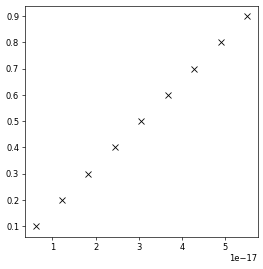

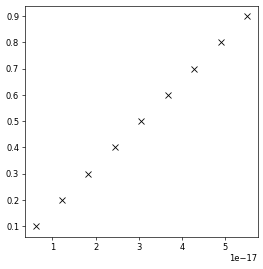

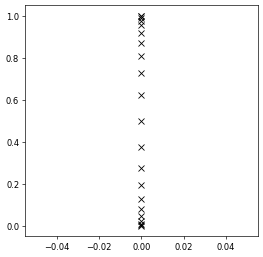

In [28]:
line = Sline2d(0, 0, 0, 1)
print(line.distribute_points(n=9, spacing='constant', factor=0.5, trim_ij=True, _plot_=True))
print(line.distribute_points(n=9, spacing='constant', factor=0, trim_ij=True, _plot_=True))
# MORE EXAMPLES NEEDED
print(line.distribute_points(n=[10, 10],
                       spacing='constant', factor=0.5,
                       sub_spacing=['cubic','cubic'],
                       subfactors=[0, 1],
                       trim_ij=True,
                       _coord_rounding_=(True, 8),
                       _plot_=True))

### divide_at_ratios

Use `divide_at_ratios` to split a line at custom fractions, returning points/lines/multiline aggregates for downstream use.

In [29]:
LINE = sl2d(-3,-5,  2,2)
ratios = [0.2, 0.3, 0.4]
points, lines, mullines = LINE.divide_at_ratios(ratios)
mullines.lines

[UPXO-sl2d (-3.0,-5.0)-(-2.0,-3.6). 2302098912640,
 UPXO-sl2d (-2.0,-3.6)-(-1.5,-2.9). 2300090383616,
 UPXO-sl2d (-1.5,-2.9)-(-1.0,-2.2). 2300089815872,
 UPXO-sl2d (-1.0,-2.2)-(2.0,2.0). 2300089815104]

### is_normal
#### Explanations
Return Truth value list for normality check between self and lines.

#### Parameters
- **lines**: Iterable of UPXO lines.
- **`_tol_decplace_`**: Number of rounding decimal places for gradient product
    check. Defaults to 8.

Generate normal vectors at ratios 0/0.5/1 and call `is_normal` to verify orthogonality across multiple candidate lines.

In [30]:
LINE = sl2d(-1.25, 1.068, 6.163, -8.012)
nv1 = LINE.normal_vector(ratio=0.0, return_type='sl2d')
nv2 = LINE.normal_vector(ratio=0.5, return_type='sl2d')
nv3 = LINE.normal_vector(ratio=1.0, return_type='sl2d')
LINE.is_normal((nv1, nv2, nv2))

[True, True, True]

### normal_vector
Find normal vector centred at starting point.

Compute and visualize normal vectors returned as `Sline2d`, checking perpendicularity and distances to another line.

In [31]:
LINE = sl2d(-1.25, 1.068, 6.163, -8.012)
nv1 = LINE.normal_vector(ratio=0.0, return_type='sl2d')
nv2 = LINE.normal_vector(ratio=0.5, return_type='sl2d')
nv3 = LINE.normal_vector(ratio=1.0, return_type='sl2d')
print(LINE.is_normal((nv1, nv2, nv3)))

normal = LINE.normal_vector(ratio=0.5, return_type='sl2d')
line = Sline2d(0, 0, 0, 1)
# CHECK:
print(line.is_normal(normal))
print(line.distance_to_lines(normal, refi='i', refj='all'))

[True, True, True]
[False]
[array([[7.47474645, 4.25313722, 7.00042874]])]


### stretch

Stretch a line about given anchors and scaling factors to observe endpoint updates after consecutive operations.

In [32]:
line = Sline2d(0, 0, 1, 0)
line.stretch([0, 0], 1)
print(line)
line.stretch([0, 0], 0.5)
print(line)
line.stretch([0.5, 0], 0.5)
print(line)
line.stretch([0, 0], 1)
print(line)

UPXO-sl2d (0,0)-(1,0). 2300090383136
UPXO-sl2d (0.0,0.0)-(0.5,0.0). 2300090383136
UPXO-sl2d (0.25,0.0)-(0.5,0.0). 2300090383136
UPXO-sl2d (0.25,0.0)-(0.5,0.0). 2300090383136


### distribute_normal_vectors

Show multiple `distribute_normal_vectors` strategies: defaults, spacing options, points-driven, and factor-generated normals with visualization.

Invalid method specified.


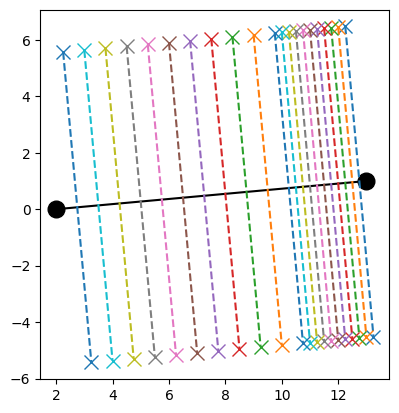

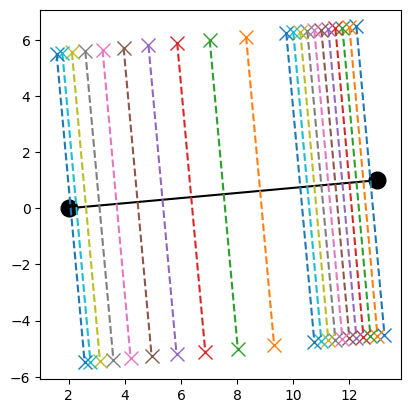

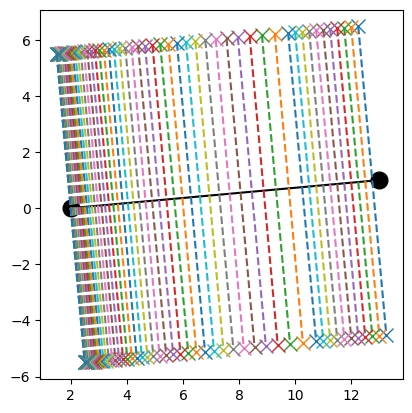

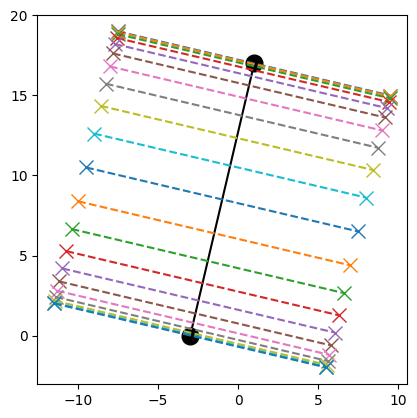

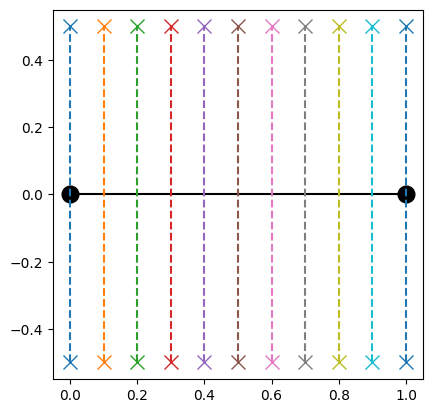

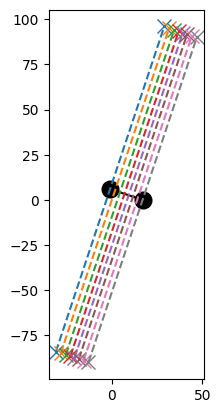

In [33]:
from upxo.geoEntities.sline2d import Sline2d as sl2d

# Exanple-1. Using default values
# -------------------------------
line = Sline2d(*np.random.randint(-10, 20, 3))
normals = line.distribute_normal_vectors(5)
print(normals)
# line.plot(sl2d=normals)

# Examples-2, 3, 4
# ----------------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(*np.random.randint(-10, 20, 3))

# Example-2
# .........
spacing_opt={'n': [10, 10], 'spacing': 'constant',
             'factor': 0.25, 'sub_spacing': ['constant', 'constant'],
             'subfactors': [0, 1], 'trim_ij': True,
             '_coord_rounding_': (True, 8), '_plot_': True}
normals = line.distribute_normal_vectors(method='by_spacing',
                                         spacing_opt=spacing_opt)
plt.figure()
line.plot(sl2d=normals)

# Example-3
# .........
spacing_opt={'n': [10, 10], 'spacing': 'constant',
             'factor': 0.25, 'sub_spacing': ['constant', 'quadratic'],
             'subfactors': [0, 1], 'trim_ij': True,
             '_coord_rounding_': (True, 8), '_plot_': True}
normals = line.distribute_normal_vectors(method='by_spacing',
                                         spacing_opt=spacing_opt)
plt.figure()
line.plot(sl2d=normals)
# Example-4
# .........
spacing_opt={'n': [10, 50], 'spacing': 'constant',
             'factor': 0.25, 'sub_spacing': ['constant', 'cubic'],
             'subfactors': [0, 1], 'trim_ij': True,
             '_coord_rounding_': (True, 8), '_plot_': True}
normals = line.distribute_normal_vectors(method='by_spacing',
                                         spacing_opt=spacing_opt)
plt.figure()
line.plot(sl2d=normals)

# Example-5
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(*np.random.randint(-10, 20, 3))
points=line.distribute_points(n=[10, 10],
                              spacing='constant', factor=0.5,
                              sub_spacing=['cubic','cubic'],
                              subfactors=[0, 1],
                              trim_ij=True,
                              _coord_rounding_=(True, 8),
                              _plot_=False)
normals = line.distribute_normal_vectors(method='by_points', points=points)
plt.figure()
line.plot(sl2d=normals)

# Example-5
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(*np.random.randint(-10, 20, 3))
line = Sline2d(0, 0, 1, 0)
points, lines, mullines = line.divide_at_ratios([0.1, 0.2, 0.3, 0.4,
                                                 0.5, 0.6, 0.7, 0.8,
                                                 0.9])
normals = line.distribute_normal_vectors(method='by_points', points=points)
plt.figure()
line.plot(sl2d=normals)

# Example-6
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(*np.random.randint(-10, 20, 3))
f = line.generate_factors_0_and_1(dx1=0.15, dx2=0.15, dmean=0.15, k=0.2, th_res=0.02)
points, lines, mullines = line.divide_at_ratios(f)
normals = line.distribute_normal_vectors(method='by_points', points=points)
for normal in normals:
    normal.stretch(normal.mid_coord, 10)
plt.figure()
line.plot(sl2d=normals)

### distance_to_points
Calculate the Baudhāyana distance between self and list of points.
### Parameters
- **points**: List of points
- **ref**: Refers to point(s) location on the sline. Options include:
    * 'all': uses location i, j and the mid on the line.
    * 'i': starting point, (x0, y0)
    * 'j': starting point, (x1, y1)
    * 'mid': middle point.

Compute Baudhāyana distances from a line to random `Point2d` samples using different reference positions (`all`, `i`, `mid`, `j`).

In [34]:
from upxo.geoEntities.point2d import Point2d as p2d
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0)
points = [p2d(xy[0], xy[1]) for xy in np.random.random((4,2))]
print(line.distance_to_points(points, ref='all'))
print(line.distance_to_points(points, ref='i'))
print(line.distance_to_points(points, ref='mid'))
print(line.distance_to_points(points, ref='j'))

[array([1.01317154, 1.10175907, 0.55014372, 0.33468527]), array([0.55850232, 0.85329612, 0.65376876, 0.28088763]), array([0.31198255, 0.86160054, 1.02575294, 0.73877026])]
[1.01317154 1.10175907 0.55014372 0.33468527]
[0.55850232 0.85329612 0.65376876 0.28088763]
[0.31198255 0.86160054 1.02575294 0.73877026]


### distance_to_lines
#### Explabation
Calculate the Baudhāyana distance between self and list of edges.

#### Parameters
- **lines**: List of lines
- **method**: Indicate the method of calculation. Can take following values:
    * 'ref': Use the referece location specifiers to calculate
    disatance. That is, use refi and refj.
    * 'min': Minimum Baudhāyana distance
    * 'max': MAximum Baudhāyana distance
    * 'mean': Mean Baudhāyana distance
- **refi**: reference location for self i.e. i
- **refj**: referecne location for the other edge i.e. j

#### Return
List of distances to all edges.

Evaluate `distance_to_lines` with multiple parallel offsets, comparing ref combinations (`mid-mid`, `i-i`, `mid-all`, `all-all`) to illustrate aggregation behavior.

In [35]:
rline = sl2d(0, 0, 1, 0)
lines = [sl2d(0, i, 1, i) for i in range(1, 10)]
print('Mid-point to Mid-point\n\n', rline.distance_to_lines(lines, refi='mid', refj='mid'), '\n', 40*'-')
print('Start-point to Start-point\n\n', rline.distance_to_lines(lines, refi='i', refj='i'), '\n', 40*'-')
print('Mid-point to All-points\n\n', rline.distance_to_lines(lines, refi='mid', refj='all'), '\n', 40*'-')

print('All-points to All-points of 1st line of lines\n\n', rline.distance_to_lines(lines, refi='all', refj='all')[0], '\n', 40*'-')
print('All-points to All-points of 2nd line of lines\n\n', rline.distance_to_lines(lines, refi='all', refj='all')[1], '\n', 20*'-')
print('All-points to All-points of 3rd line of lines\n\n', rline.distance_to_lines(lines, refi='all', refj='all')[2])

Mid-point to Mid-point

 [array([[1.]]), array([[2.]]), array([[3.]]), array([[4.]]), array([[5.]]), array([[6.]]), array([[7.]]), array([[8.]]), array([[9.]])] 
 ----------------------------------------
Start-point to Start-point

 [array([[1.]]), array([[2.]]), array([[3.]]), array([[4.]]), array([[5.]]), array([[6.]]), array([[7.]]), array([[8.]]), array([[9.]])] 
 ----------------------------------------
Mid-point to All-points

 [array([[1.11803399, 1.        , 1.11803399]]), array([[2.06155281, 2.        , 2.06155281]]), array([[3.04138127, 3.        , 3.04138127]]), array([[4.03112887, 4.        , 4.03112887]]), array([[5.02493781, 5.        , 5.02493781]]), array([[6.02079729, 6.        , 6.02079729]]), array([[7.01783442, 7.        , 7.01783442]]), array([[8.01560977, 8.        , 8.01560977]]), array([[9.01387819, 9.        , 9.01387819]])] 
 ----------------------------------------
All-points to All-points of 1st line of lines

 [[1.         1.11803399 1.41421356]
 [1.1180339

### translate_by
#### Explanations
Translate the Edge by a Euclidean distance. Details: Translate the Edge along the vector by a given distance. If update is True, then coords of the self will be updated. If throw is True and update is False, a new edge of the new coordinates shall be returned. If throw is True and update is True, a deepcopy of the self shall be returned.

#### Parameters
- **vector**: Direction of translation. Two specifications allowed are:
    - Specification 1: [vector start point coords, vector end point coords]
    - Specification 2: 'x+', 'z-'
- **dist**: Euclidean distance. If None and not a Number, then the translation distrance will be the lenght of the vector. If a number, then dist will be the translation distance, in which case the vector will only be used to know the translation direction.
- **update**: Update the current point if True, do not update if False.
- **throw**: Return a edge if True, else return nothing if False.

#### Return
- **UPXO edge object**: Conditional, depending on input throw (refer to description).

Placeholder noting translation-by-vector examples are pending for `translate_by`.

In [36]:
# Code tp be developed

### intersection_lines

#### Parameters
- **lines**: Data representing 2D and/or 3D lines.
- **dim**: dimensionality. Default to 2. Options are
    - 2D.
    - 3D.
    - 2D/3D - indicates mixed collection in lines user input.

Test `intersection_lines` on mixed crossing/parallel cases to see intersection detection with different query lines.

In [37]:
lines = [sl2d.by_coord([-1, -1], [3, 3]),
         sl2d.by_coord([-1, 1], [1, -1]),
         sl2d.by_coord([0, 0], [1, 0]),
         sl2d.by_coord([0, 0], [0, 1]) ]
print(sl2d.by_coord([0, 0], [0, 1]).intersection_lines(lines))
print(sl2d.by_coord([1, 0], [1, 1]).intersection_lines(lines))

[[nan, nan], [nan, nan], [nan, nan], [nan, nan]]
[[nan, nan], [nan, nan], [nan, nan], [nan, nan]]


### rectangle
#### Explanations
Return rectangle form of line. Details: Convert self line into rectangle of length equal to line.length and width equal to the user specified width. Rectangle will completely bound the line. Ednd points of line will be at midpoints of corresponding opposite lines of the rectangle.

#### Parameters
- **width**: width of the rectangle.

#### Return
- **coords**: list of [p1, p2, p3, p4]. CCW from lower left point, p1.
- **rectangle**: Shapely polygon object

Generate rectangles around various line orientations with `rectangle(width, vis=True)` to visualize bounding polygons and returned Shapely polygons.

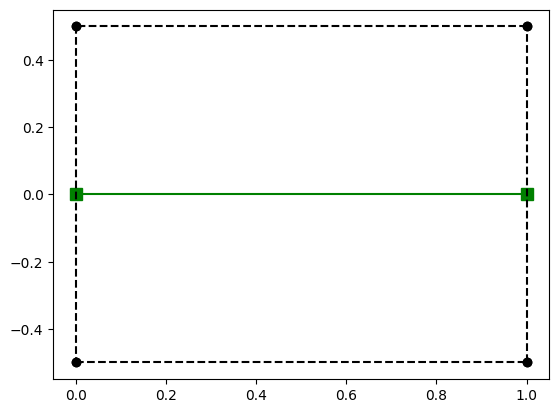

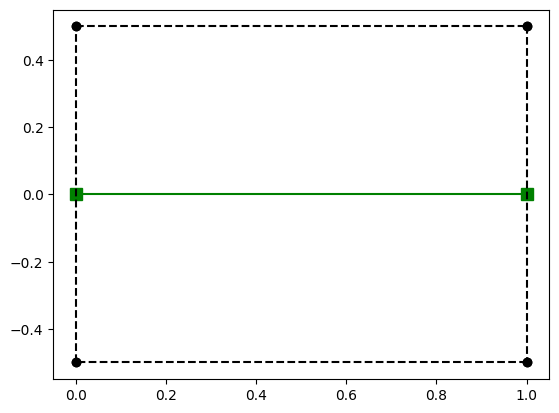

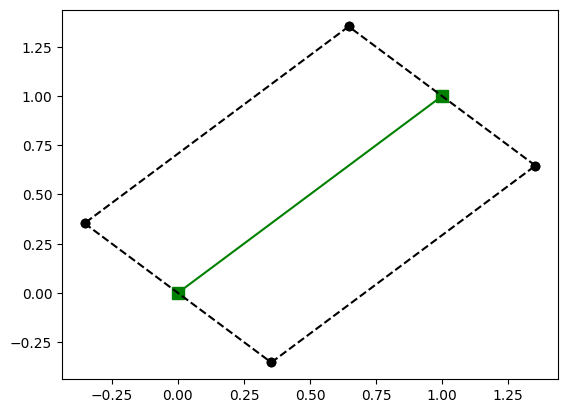

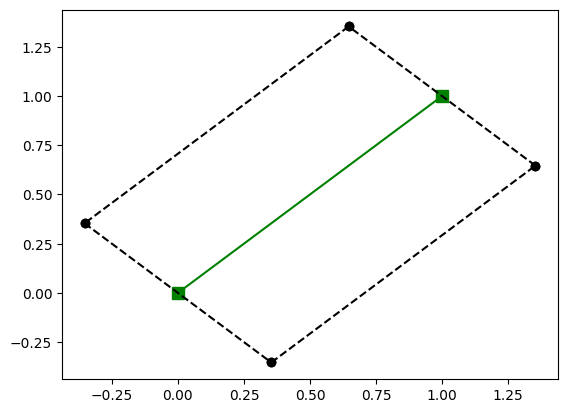

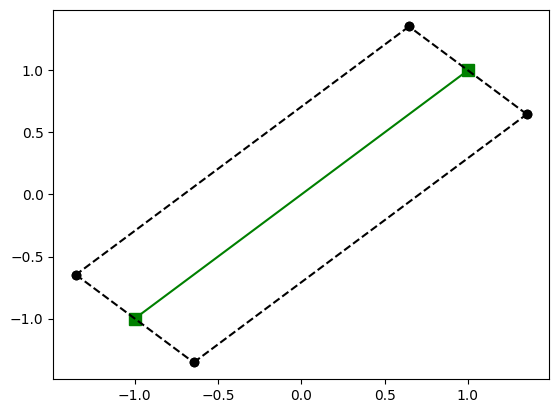

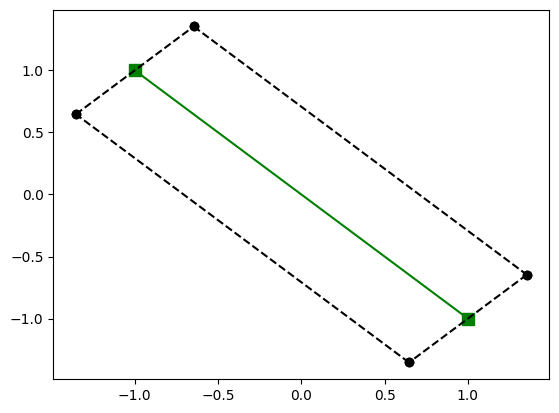

In [38]:
from upxo.geoEntities.sline2d import Sline2d as sl2d
# ---------------------------
line = sl2d(0, 0, 1, 0)
plt.figure()
_, r = line.rectangle(1, vis=True)
# ---------------------------
line = sl2d(1, 0, 0, 0)
plt.figure()
_, r = line.rectangle(1, vis=True)
# =======================================
from upxo.geoEntities.sline2d import Sline2d as sl2d
# ---------------------------
line = sl2d(0, 0, 1, 1)
plt.figure()
_, r = line.rectangle(1, vis=True)
# ---------------------------
line = sl2d(1, 1, 0, 0)
plt.figure()
_, r = line.rectangle(1, vis=True)
# ---------------------------
line = sl2d(-1, -1, 1, 1)
plt.figure()
_, r = line.rectangle(1, vis=True)
# ---------------------------
line = sl2d(1, -1, -1, 1)
plt.figure()
_, r = line.rectangle(1, vis=True)

### identify_points_in_rectangle
#### Explanation
Identify points which lie inside rectangle of the line. Details: For a given set of points list, this function returns the
indices of those points which are inside (and, on) the boundary of rectangle made from the self line (using width, of course).

#### Parameters
- **points**: coordinates as [[x-coords],[y-coords]]
- **width**: rectangle width
- **boundary_points**: If True, points on the boundry of the rectangle will be considered, else not.
- **vis**: If True, a quick visualization will be provided. Green is for self line, where smaller is startiung point i and larger is ending point j. Markewr sizes indicating corners of rectangle follow shapely polygon coordinate order. Black dots are points. Blue crosses are points which satisfy the geometric condition. *NOTE*: The above order may differ from UPXO line.rectangle.

#### Return
- **inside**: Numpy arrau of bools. A True indicates position in input
    points which satisfy the geometric criteria.

Run `identify_points_in_rectangle` across multiple line/point grids to see which points fall inside the line’s bounding rectangle, with visualization toggled.

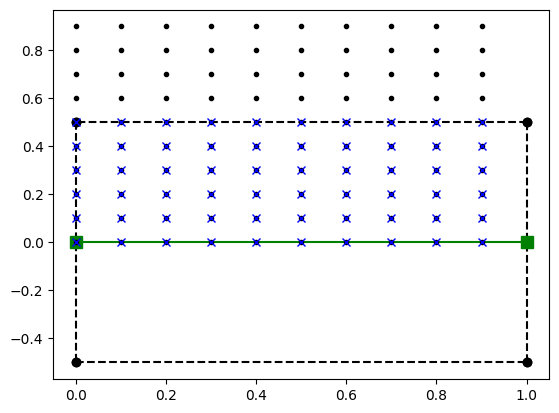

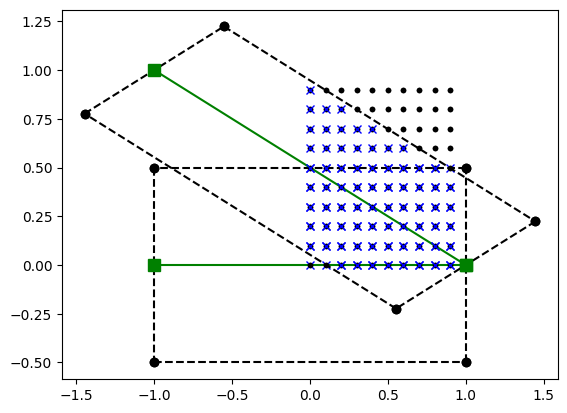

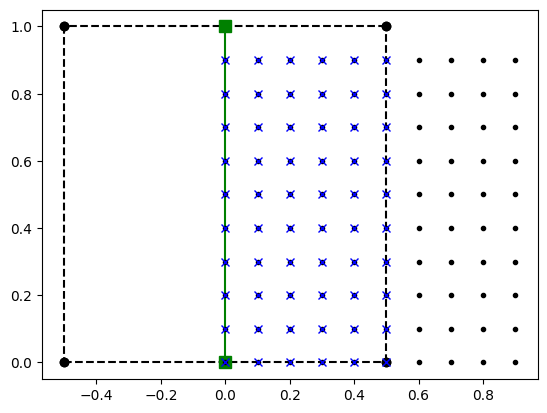

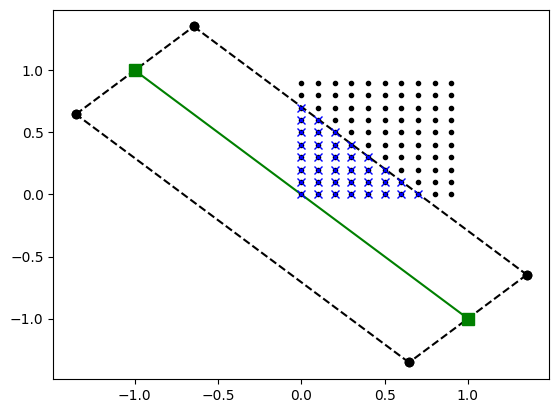

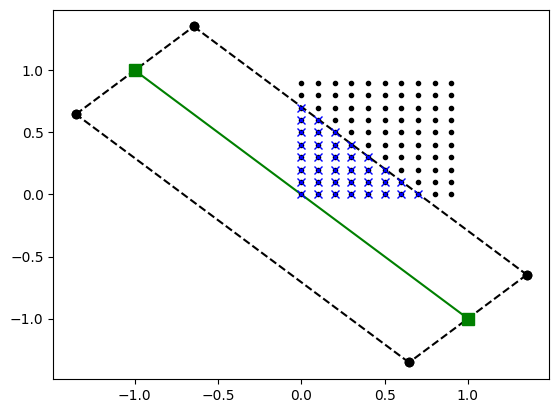

In [39]:
# Examples
# --------
from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.sline2d import Sline2d as sl2d

# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0)
_x, _y = np.arange(0, 1, 0.1), np.arange(0, 1, 0.1)
x, y = np.meshgrid(_x, _y)
plt.figure()
inside = line.identify_points_in_rectangle([x.ravel(), y.ravel()],
                                           width=1,
                                           boundary_points=True,
                                           vis=True)

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, 0, 1, 0)
_x, _y = np.arange(0, 1, 0.1), np.arange(0, 1, 0.1)
x, y = np.meshgrid(_x, _y)
points = [x.ravel(), y.ravel()]
plt.figure()
inside = line.identify_points_in_rectangle(points, 1, True, True)

# Example-3
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, 1, 1, 0)
_x, _y = np.arange(0, 1, 0.1), np.arange(0, 1, 0.1)
x, y = np.meshgrid(_x, _y)
inside = line.identify_points_in_rectangle(points, 1, True, True)

# Example-4
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 0, 1)
_x, _y = np.arange(0, 1, 0.1), np.arange(0, 1, 0.1)
x, y = np.meshgrid(_x, _y)
plt.figure()
inside = line.identify_points_in_rectangle(points, 1, True, True)

# Example-5
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(1, -1, -1, 1)
_x, _y = np.arange(-2, 2, 0.1), np.arange(-2, 2, 0.1)
x, y = np.meshgrid(_x, _y)
plt.figure()
inside = line.identify_points_in_rectangle(points, 1, True, True)

# Example-6
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(1, -1, -1, 1)
_x, _y = np.arange(-2, 2, 0.1), np.arange(-2, 2, 0.1)
x, y = np.meshgrid(_x, _y)
plt.figure()
inside = line.identify_points_in_rectangle(points, 1, True, True)

### perp_distance

Compute perpendicular distances from lines to scalars, numpy grids, and `Point2d` lists to compare output shapes and ptype handling.

In [40]:
# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
from upxo.geoEntities.point2d import Point2d as p2d
line = sl2d(0, 0, 1, 1)
plist = (0.1, 0.1)
print(line.perp_distance(plist))

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0.0)
plist = np.random.random((4, 2)).T
print(line.perp_distance(plist))

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0.0)
plist = [p2d(1, 1), p2d(1, 2), p2d(1, 3), p2d(1, 4), p2d(1, 5)]
print(line.perp_distance(plist, ptype = '[point2d]'))

0.0
[0.41911361 0.03335731 0.17654621 0.1592349 ]
[1. 2. 3. 4. 5.]


### find_neigh_point_by_perp_distance

#### Explanations
Find the neighbouring point(s) in a list of points by perp distance. Point subselection depends on whether a point is within OR on the cut-off perpendicular distance, r.

#### Parameters
- **plist**: Elements of plist must contain the coordinates either in direct Iterable form (such a list of [x, y] or a nparray np.array([x, y])) OR a 2D/3D UPXO point object.
- **plane**: Specify the plane of the self point. Only used if self is a 2D
point object. Defaults to 'xy'.
- **r**: Cut-off perpendicular diatance.
   If 0, the closest point will be looked out for.
   If > 0, all points which fall in or on a circle of radius r will be
   looked out for.

#### Return
Indices in plist. Empty list if no points are inside r.

Use `find_neigh_point_by_perp_distance` across several line orientations, radii, and bounding-rectangle flags to see neighbor selection sensitivity and visualization.

[3,
 4,
 5,
 6,
 7,
 16,
 17,
 18,
 19,
 20,
 29,
 30,
 31,
 32,
 33,
 42,
 43,
 44,
 45,
 46,
 55,
 56,
 57,
 58,
 59,
 68,
 69,
 70,
 71,
 81,
 82,
 83,
 94,
 95,
 107]

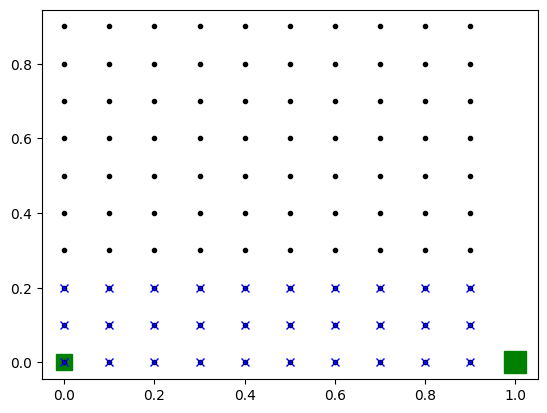

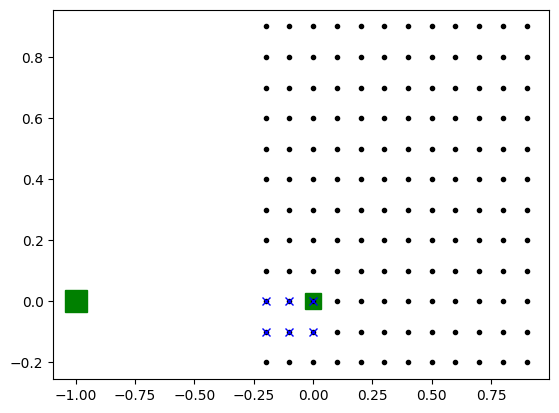

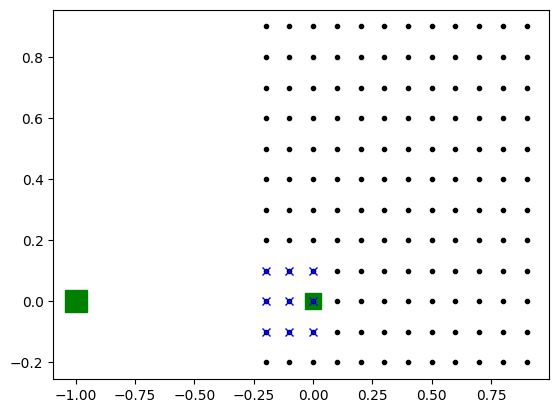

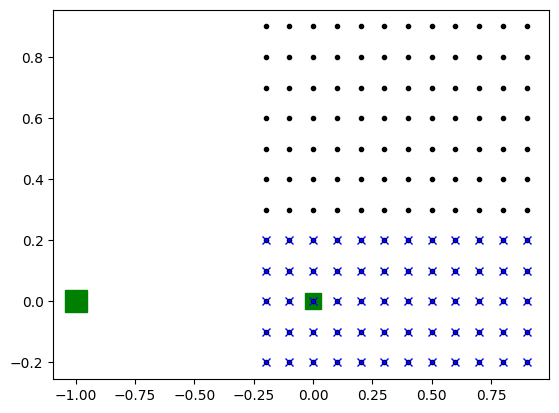

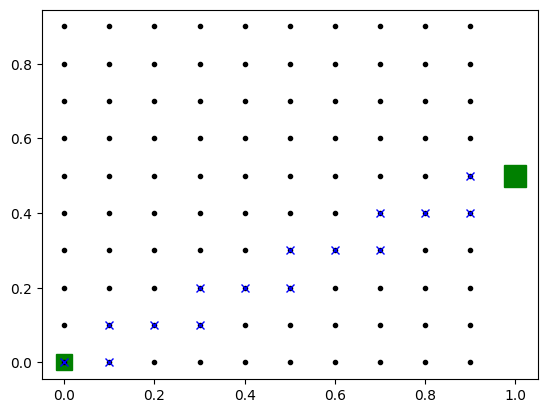

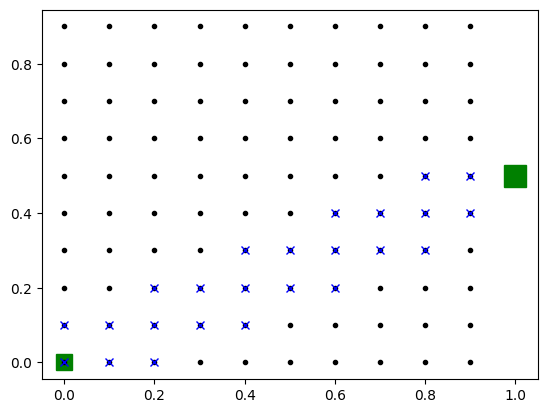

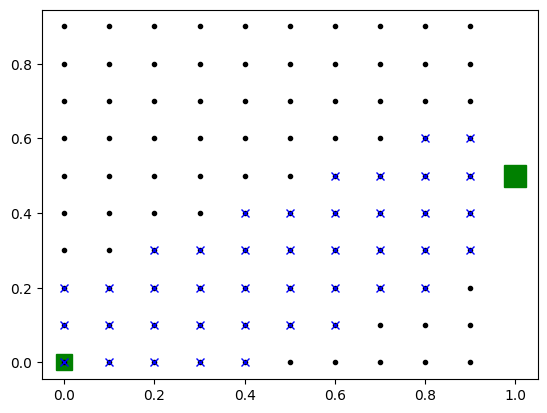

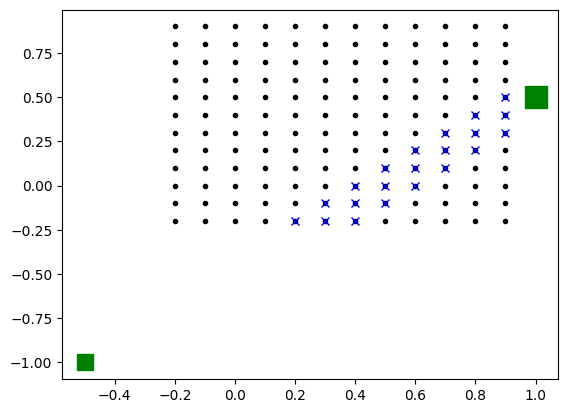

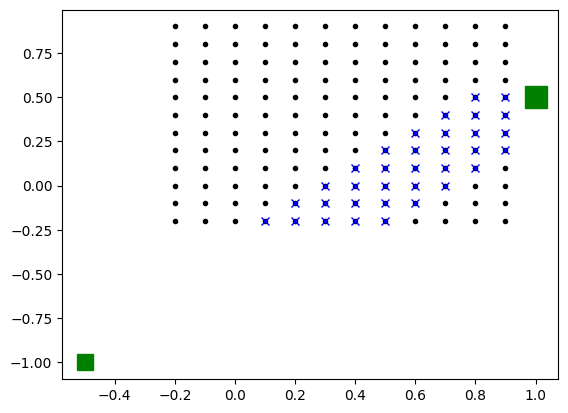

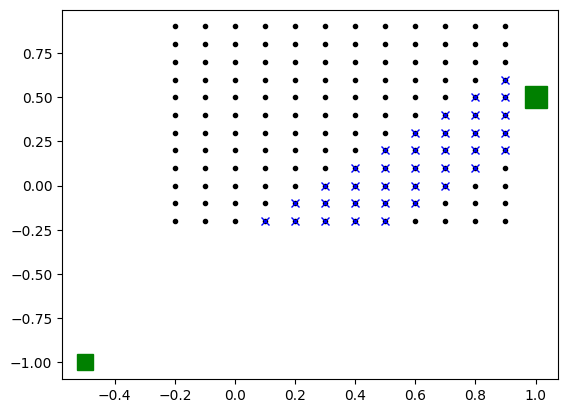

In [41]:
# Example set-1
# -------------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0)
x, y = np.meshgrid(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
points = (x.ravel(), y.ravel())
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=False, epsfactor=1E6, vis=True)

# Example set-2
# -------------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, -1, 0)
x, y = np.meshgrid(np.arange(-0.2, 1, 0.1), np.arange(-0.2, 1, 0.1))
points = (x.ravel(), y.ravel())
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=0, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=1E7, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=False, epsfactor=0, vis=True)

# Example set-3
# -------------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, 1, 0.5)
x, y = np.meshgrid(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
points = (x.ravel(), y.ravel())
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=0, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=1E7, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=False, epsfactor=0, vis=True)

# Example set-4
# -------------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-0.5, -1, 1, 0.5)
x, y = np.meshgrid(np.arange(-0.2, 1, 0.1), np.arange(-0.2, 1, 0.1))
points = (x.ravel(), y.ravel())
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=0, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=True, epsfactor=1E7, vis=True)
plt.figure()
line.find_neigh_point_by_perp_distance(points, 0.2, use_bounding_rec=False, epsfactor=0, vis=True)

### find_colinear_lines

Call `find_colinear_lines` with UPXO line objects and coordinate lists to return indices of colinear matches in varied datasets.

In [42]:
# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, -1, 0)
lines = [sl2d(0, 0, -1, 0), sl2d(0, 0, 1, 2),
         sl2d(-1, 0, -2, 0), sl2d(4, 0, 3, 0),
         sl2d(0, 0, 1, 0), sl2d(0, 1, 1, 1)]
print(line.find_colinear_lines(lines, line_repr='upxo'))

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(2, 7, 7, 3)
lines = [[[0, 9], [0, 1]],
         [[1, 8], [6, 2]],
         [[3, 8], [8, 4]],
         [[3, 6], [8, 4]],
         ]
print(line.find_colinear_lines(lines, line_repr='coord_list'))

# Example-3
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, -1, 0)
lines = [[[0, 0], [-1, 0]],
         [[0, 0], [1, 2]],
         [[-1, 0], [-2, 0]],
         [[4, 0], [3, 0]],
         [[0, 0], [1, 0]],
         [[0, 1], [1, 1]],
         [[0, 0], [-1, 0]]]
print(line.find_colinear_lines(lines, line_repr='coord_list'))

[0, 2, 3, 4]
None
[0, 2, 3, 4, 6]


### find_parallel_lines
#### Explanations
Find line amongst lines parallel to self.

#### Parameters
- **lines**: list of data representing lines
- **line_repr**: specifies the type of line representation. Valid options include (see examples below for specific information.):
    - * 'upxo'
    - * 'coord_list'

#### Return
Location indices of those lines in lines parallel to self.

Demonstrate `find_parallel_lines` on UPXO objects and raw coord lists to list indices of parallel segments relative to a reference line.

In [43]:
# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(0, 0, -1, 0)
lines = [sl2d(0, 0, -1, 0), sl2d(0, 0, 1, 2)]
print(line.find_parallel_lines(lines, line_repr='upxo'))

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(2, 7, 7, 3)
lines = [[[0, 9], [0, 1]],
         [[1, 8], [6, 2]],
         [[2, 7], [7, 3]],
         [[3, 6], [8, 4]]]
print(line.find_parallel_lines(lines, line_repr='coord_list'))

[0]
[2]


### make_points
#### Explanations
Make n points on the line.

#### Parameters
- **n**: Number of points to make
- **spacing**: mathematical spacing to apply
threshold_factor
- **start**: spacifies the location about which point creation starts.
- **store_as_feature**: If True, points will be stored in self.f dictionary.
    Defaults to False.
- **feature_replace**: If True, any existing feature points will be erased.
    DEfaults to False.
- **vis**: If True, result shall be visualized. Defaults to False.

#### Returns
points:
increments:

Generate points along a line with linear/quadratic spacing and different thresholds/start anchors, plotting distributions.

([uxpo-p2d (0.8333333333333334,0.8333333333333334),
  uxpo-p2d (0.6666666666666667,0.6666666666666667),
  uxpo-p2d (0.5,0.5),
  uxpo-p2d (0.33333333333333337,0.33333333333333337),
  uxpo-p2d (0.16666666666666674,0.16666666666666674)],
 array([0.23570226, 0.47140452, 0.70710678, 0.94280904, 1.1785113 ]))

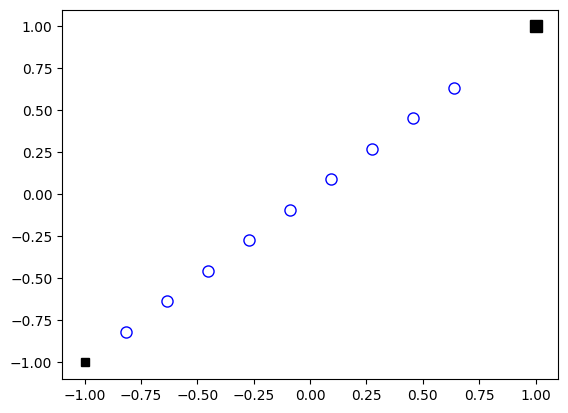

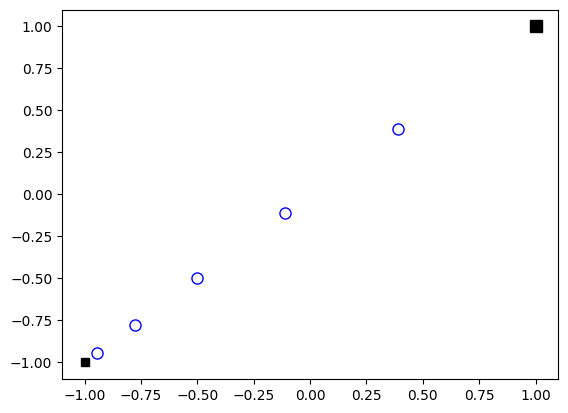

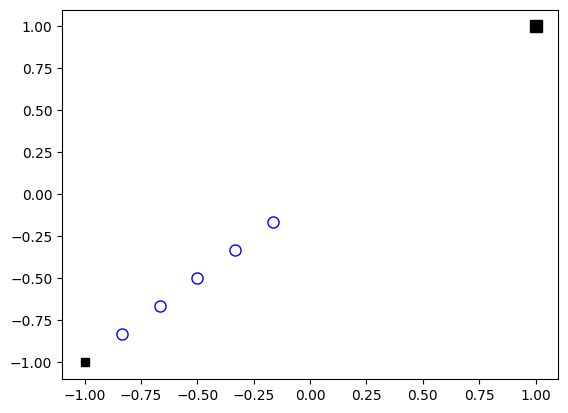

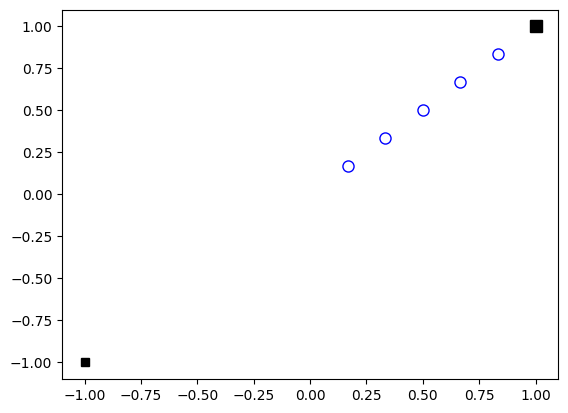

In [44]:
# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, -1, 1, 1)
line.make_points(10, spacing='linear', threshold_factor=1.0, vis=True)

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, -1, 1, 1)
line.make_points(5, spacing='quadratic', threshold_factor=1.0, vis=True)

# Example-3
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, -1, 1, 1)
line.make_points(5, spacing='linear', threshold_factor=0.5, vis=True)

# Example-4
# ---------
from upxo.geoEntities.sline2d import Sline2d as sl2d
line = sl2d(-1, -1, 1, 1)
line.make_points(5, spacing='linear', threshold_factor=0.5, start='j', vis=True)

### generate_points

Generate perturbed points along a line at fixed spacing to illustrate stochastic jitter via `pert_factor`.

In [46]:
line = Sline2d(0, 0, 1, 1)
line.generate_points(np.sqrt(2)/10, pert_factor=1)

[(0.10659739413386363, 0.10659739413386363),
 (0.21023372759127815, 0.21023372759127815),
 (0.29382171154440556, 0.29382171154440556),
 (0.3854163949028411, 0.3854163949028411),
 (0.47531073977568294, 0.47531073977568294),
 (0.5804736288428498, 0.5804736288428498),
 (0.6693356739946074, 0.6693356739946074),
 (0.8392253719870686, 0.8392253719870686),
 (0.8746892746926275, 0.8746892746926275)]

### translate_along_normals

Translate a base line along its normals via count- and distance-based schemes, including random perturbations and plotting of generated offset lines.

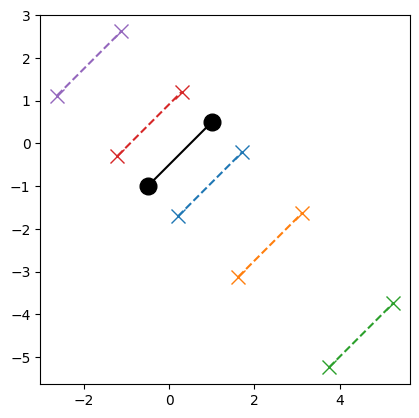

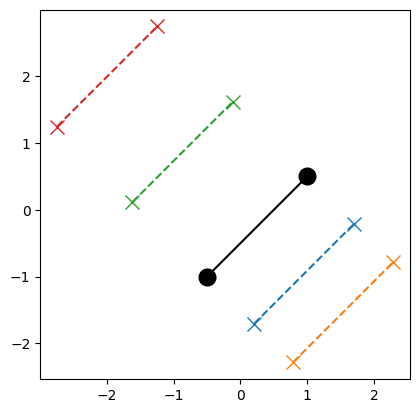

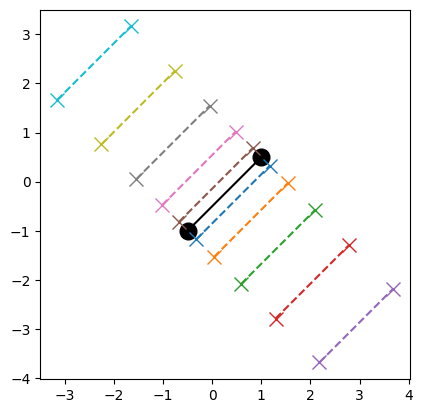

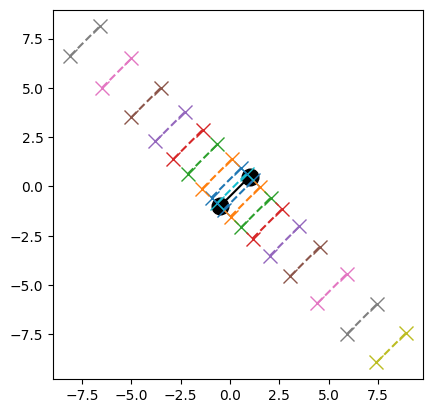

In [52]:
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)
# ----------------------------------------------------------
lines = line.translate_along_normals(method='by_count', nlines=[3, 2])
plt.figure()
line.plot(sl2d=lines)
# ----------------------------------------------------------
lines = line.translate_along_normals(method='by_distances',
                                     nlines=[[1.0, 2.0], [1.5, 3.0]],
                                     pert=0.1)
plt.figure()
line.plot(sl2d=lines)
# ----------------------------------------------------------
spacing={'dist': 'normal', 'mean': 0.25, 'std_factor': 0.025}
lines = line.translate_along_normals(method='by_count', nlines=[5, 5],
                                     spacing=spacing)
plt.figure()
line.plot(sl2d=lines)
# ----------------------------------------------------------
spacing = {'dist': 'normal', 'mean': 0.25, 'std_factor': 0.1015}
lines = line.translate_along_normals(method='by_count', nlines=[20,20],
                              spacing=spacing, dmax=[12.5, 12.5])
plt.figure()
line.plot(sl2d=lines)

### translate_along_normals_2

Use `translate_along_normals_2` with count- and distance-based inputs plus optional perturbation to produce symmetric offset copies and visualize them.

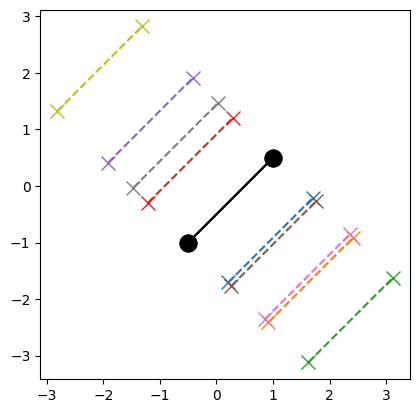

In [55]:
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)

# Create 3 copies in one direction and 2 in the other, spaced unit distance apart
translated_lines = line.translate_along_normals_2(
    method='by_count',
    d=[3, 2]
)
line.plot(sl2d=translated_lines)

translated_lines = line.translate_along_normals_2(
method='by_distances',
d=[[1.0, 2.0], [1.5, 3.0]],
perturbation=0.1
)
line.plot(sl2d=translated_lines)

### translate_along_normals_1

Translate along normals via `translate_along_normals_1` to generate evenly spaced offsets on either side of the source line, then plot them.

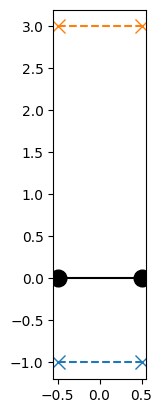

In [57]:
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)
line.translate_along_normals_1(d=[1, 20])

line = Sline2d(-0.5, 0, 0.5, 0)
# line.plot()
line.plot(sl2d=line.translate_along_normals_1(d=[1, 3]))

### array_translation

Demonstrate `array_translation` to clone a line multiple times along a given vector or its normal, with optional trimming and combined directional arrays, plus plots.

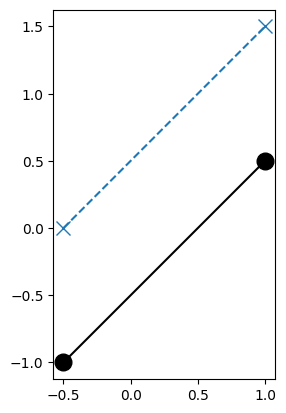

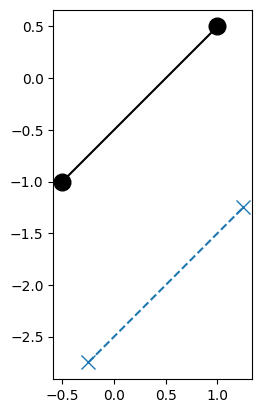

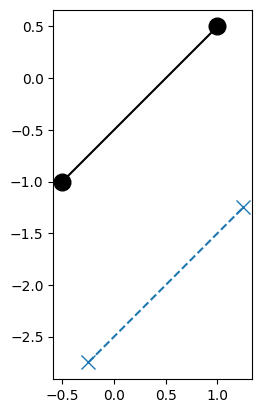

In [60]:
# Example-1
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)
lines = line.array_translation(ncopies=2, vector=[0, 1], spacing='constant')
plt.figure()
line.plot(sl2d=lines)

# Example-2
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)
nv = line.normal_vector(ratio=0.0, return_type='sl2d')
lines = line.array_translation(ncopies=1, vector=[nv.x0, nv.y0], spacing='constant', trim_self=True)
plt.figure()
line.plot(sl2d=lines)

# Example-3
# ---------
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-0.5, -1, 1, 0.5)
nv = line.normal_vector(ratio=0.0, return_type='sl2d')
lines_A = line.array_translation(ncopies=1, vector=[nv.x0, nv.y0], spacing='constant', trim_self=True)
lines_B = line.array_translation(ncopies=1, vector=[-nv.x0, -nv.y0], spacing='constant', trim_self=True)
lines = lines_A + lines_B
plt.figure()
line.plot(sl2d=lines)

### split
#### Explanations
Split the self.line at location(s) specified.

#### Prameters
- **f**: specifies the locat5ions. Can be a numeric value or an iterable of numerical values. All values must be in the domain (0, 1).

Split a line by factor, point object, or raw coordinate divider while controlling which endpoint updates and whether new segments are returned.

In [64]:
from upxo.geoEntities.sline2d import Sline2d as sl2d

line = sl2d(0,0, 1,0)
print(line.split(method='factor', f=0.75, saa=True, throw=True, update='pnta'))

line = sl2d(0,0, 1,0)
print(line.split(method='factor', f=0.75, saa=True, throw=True, update='pntb'))

line = sl2d(0,0, 1,0)
print(line.split(method='p2d', divider=Point2d(0.05, 0), saa=True, throw=True, update='pntb'))

line = sl2d(0,0, 1,0)
print(line.split(method='p2d', divider=Point2d(0.05, 0), saa=True, throw=True, update='pnta'))

# line = sl2d(0,0, 1,0)
# line.split(method='p2d', divider=Point2d(0.00, 0), saa=True, throw=True, update='pntb')

line = sl2d(0,0, 1,0)
print(line.split(method='coord', divider=(0.05, 0), saa=True, throw=True, update='pnta'))

# line = sl2d(0,0, 1,0)
# line.split(method='coord', divider=(0.0, 0), saa=True, throw=True, update='pnta')

(UPXO-sl2d (0.75,0.0)-(1,0). 2302101817184, UPXO-sl2d (0,0)-(0.75,0.0). 2300120324896)
(UPXO-sl2d (0,0)-(0.75,0.0). 2300120324896, UPXO-sl2d (0.75,0.0)-(1,0). 2302101817184)
(UPXO-sl2d (0,0)-(0.05,0). 2302101817184, UPXO-sl2d (0.05,0)-(1,0). 2300120324896)
(UPXO-sl2d (0.05,0)-(1,0). 2300120324896, UPXO-sl2d (0,0)-(0.05,0). 2302101817184)
(UPXO-sl2d (0.05,0)-(1,0). 2302101817184, UPXO-sl2d (0,0)-(0.05,0). 2300120324896)
